In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train=pd.read_csv('./train.csv')
df_test=pd.read_csv('./test.csv')

df_train.head()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
0,0,25.0,0.50,0.25,0.75,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146
1,1,25.0,0.50,0.25,0.50,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201
2,2,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760
3,3,12.5,0.25,0.25,0.63,0.50,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590
4,4,25.0,0.50,0.25,0.63,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417


##训练集概览和清洗

In [3]:
# 查看有无缺失值
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15289 entries, 0 to 15288
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    15289 non-null  int64  
 1   clonesize             15289 non-null  float64
 2   honeybee              15289 non-null  float64
 3   bumbles               15289 non-null  float64
 4   andrena               15289 non-null  float64
 5   osmia                 15289 non-null  float64
 6   MaxOfUpperTRange      15289 non-null  float64
 7   MinOfUpperTRange      15289 non-null  float64
 8   AverageOfUpperTRange  15289 non-null  float64
 9   MaxOfLowerTRange      15289 non-null  float64
 10  MinOfLowerTRange      15289 non-null  float64
 11  AverageOfLowerTRange  15289 non-null  float64
 12  RainingDays           15289 non-null  float64
 13  AverageRainingDays    15289 non-null  float64
 14  fruitset              15289 non-null  float64
 15  fruitmass          

In [4]:
# 查看重复行的数量
df_train.duplicated().sum()

0

In [5]:
# 删除id列
df_train=df_train.drop(columns='id')
# 查看描述性信息
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
clonesize,15289.0,19.704690,6.595211,10.000000,12.500000,25.000000,25.000000,40.000000
honeybee,15289.0,0.389314,0.361643,0.000000,0.250000,0.500000,0.500000,18.430000
bumbles,15289.0,0.286768,0.059917,0.000000,0.250000,0.250000,0.380000,0.585000
andrena,15289.0,0.492675,0.148115,0.000000,0.380000,0.500000,0.630000,0.750000
osmia,15289.0,0.592355,0.139489,0.000000,0.500000,0.630000,0.750000,0.750000
MaxOfUpperTRange,15289.0,82.169887,9.146703,69.700000,77.400000,86.000000,86.000000,94.600000
MinOfUpperTRange,15289.0,49.673281,5.546405,39.000000,46.800000,52.000000,52.000000,57.200000
AverageOfUpperTRange,15289.0,68.656256,7.641807,58.200000,64.700000,71.900000,71.900000,79.000000
MaxOfLowerTRange,15289.0,59.229538,6.610640,50.200000,55.800000,62.000000,62.000000,68.200000
MinOfLowerTRange,15289.0,28.660553,3.195367,24.300000,27.000000,30.000000,30.000000,33.000000


##蓝莓克隆大小与其他因素的关系分析

In [6]:
# 选出训练集中所有的数值类型的列，进行相关性分析，这个数据集里面全都是数据类型列，所以这一步可以不做
numerical_cols=df_train.select_dtypes(include=[np.number]).columns

print(numerical_cols.tolist())

# 对所有的数据列计算相关系数矩阵
corr_matrix=df_train[numerical_cols].corr()

print("克隆大小与其他变量的相关系数:")
print(corr_matrix['clonesize'].sort_values(ascending=False))

['clonesize', 'honeybee', 'bumbles', 'andrena', 'osmia', 'MaxOfUpperTRange', 'MinOfUpperTRange', 'AverageOfUpperTRange', 'MaxOfLowerTRange', 'MinOfLowerTRange', 'AverageOfLowerTRange', 'RainingDays', 'AverageRainingDays', 'fruitset', 'fruitmass', 'seeds', 'yield']
克隆大小与其他变量的相关系数:
clonesize               1.000000
honeybee                0.304130
RainingDays             0.165770
AverageRainingDays      0.164823
bumbles                 0.080433
andrena                 0.065131
MaxOfLowerTRange        0.016343
MaxOfUpperTRange        0.016159
AverageOfUpperTRange    0.016057
MinOfLowerTRange        0.016026
AverageOfLowerTRange    0.015987
MinOfUpperTRange        0.015838
osmia                  -0.007607
fruitmass              -0.377688
yield                  -0.382619
seeds                  -0.396898
fruitset               -0.406793
Name: clonesize, dtype: float64


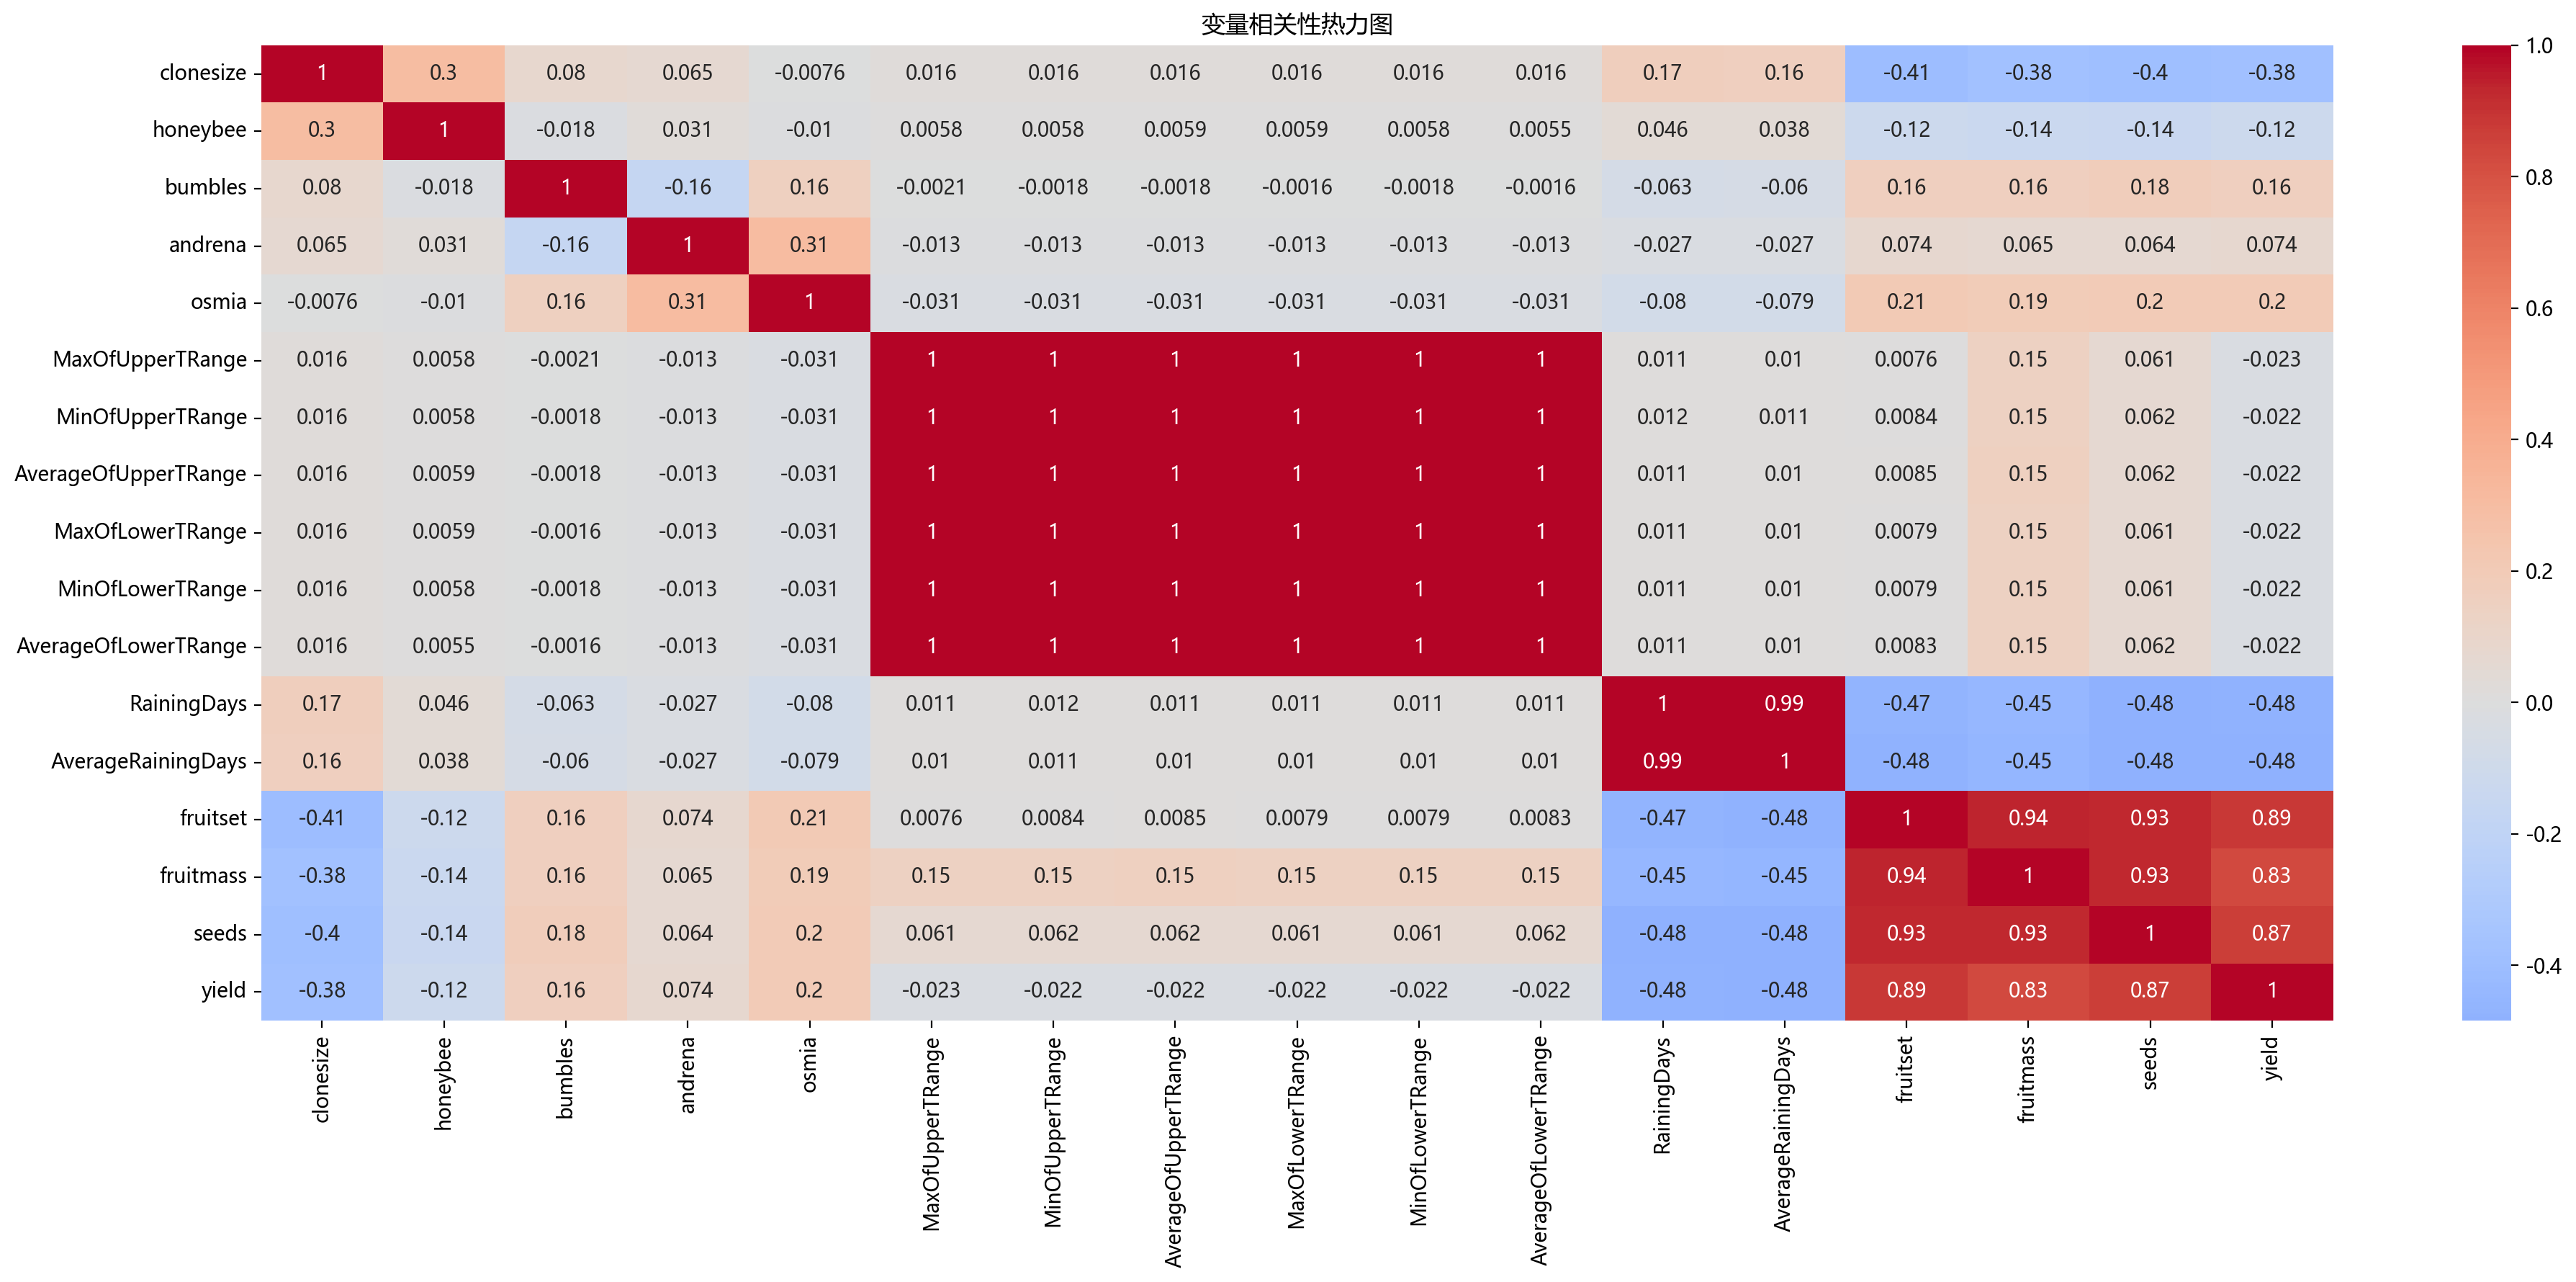

In [44]:
# 汇总热力图
plt.rcParams['font.sans-serif']=['Microsoft YaHei'] #指定中文字体为微软雅黑
plt.rcParams['axes.unicode_minus']=False # 解决负号显示为方块的问题

plt.figure(figsize=(20,9),dpi=200)
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',center=0)
plt.title('变量相关性热力图')
plt.tight_layout()

plt.savefig('变量相关热力图.png',dpi=1200,bbox_inches='tight') # 必须先savefig保存再show，否则保存出来就是空白图片

plt.show()
plt.close()

In [8]:
# 克隆株大小分类对比
# 用qcut三等分

df_train['size_group']=pd.qcut(df_train['clonesize'],q=3,labels=['小','中','大'])

print('各组分组情况：')
print(df_train['size_group'].value_counts().sort_values(ascending=False))

各组分组情况：
size_group
中    8301
小    6721
大     267
Name: count, dtype: int64


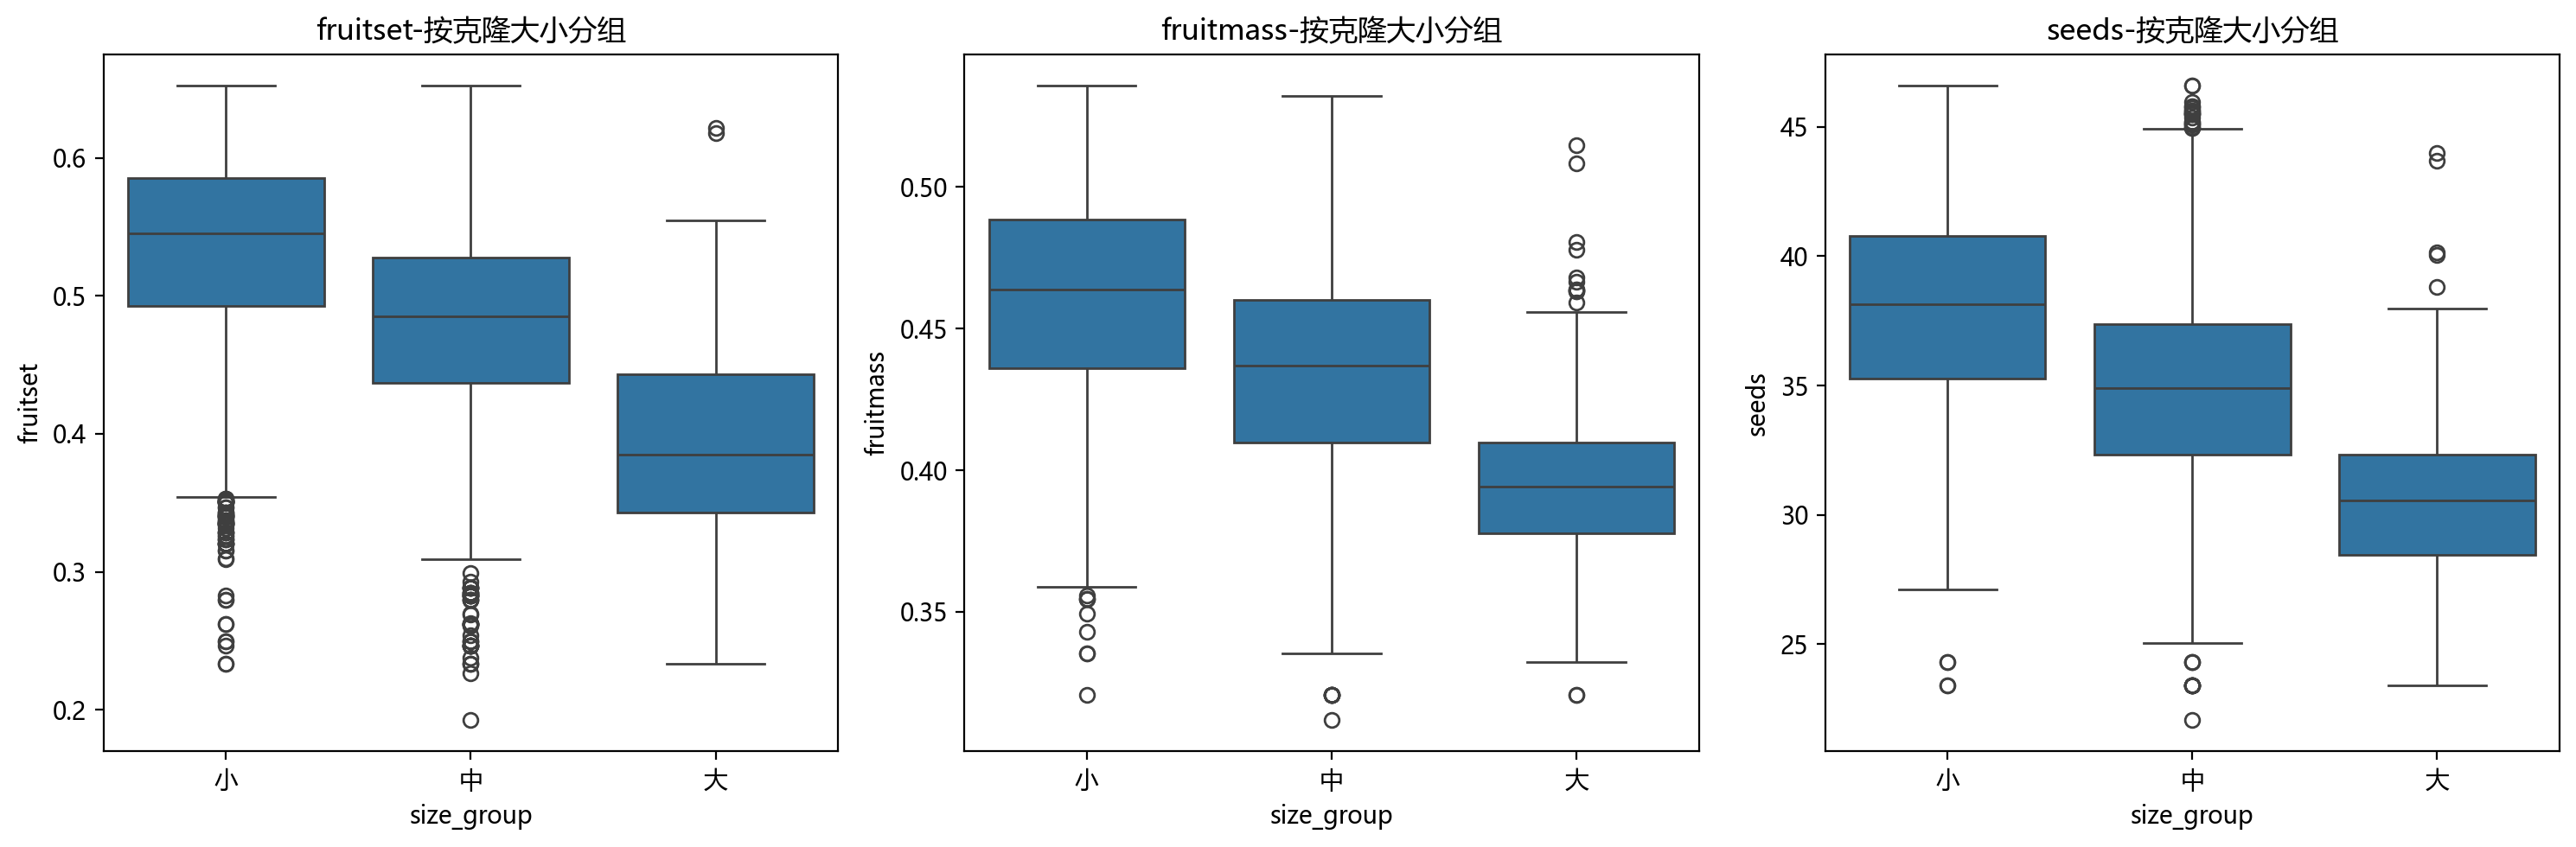

各组的平均值:
            fruitset  fruitmass      seeds
size_group                                
小           0.534743   0.461470  37.882224
中           0.480471   0.436074  34.948520
大           0.389532   0.396846  30.755928


In [45]:
#绘制箱型图对比
#选择要对比的变量
compare_vars=['fruitset','fruitmass','seeds'] #选择果实集、果实质量、种子数进行组间对比

fig,axes=plt.subplots(1,3,figsize=(15,5),dpi=200)

for i,var in enumerate(compare_vars):
    sns.boxplot(x='size_group',y=var,data=df_train,ax=axes[i])
    axes[i].set_title(f"{var}-按克隆大小分组")

plt.tight_layout()
plt.savefig('按克隆大小分组的果实质量比较.png',dpi=1200,bbox_inches='tight')

plt.show()
plt.close()

print("各组的平均值:")
print(df_train.groupby(['size_group'],observed=False)[compare_vars].mean())

In [10]:
# 检验不同克隆大小组在各变量上是否有显著差异

#导入库
from scipy.stats import pearsonr,f_oneway


print("假设检验结果(oneway_ANOVA单因素方差分析):")
print('-'*30)

for var in compare_vars:
    # 提取三组数据
    group_small=df_train[df_train['size_group']=='小'][var]
    group_medium=df_train[df_train['size_group']=='中'][var]
    group_large=df_train[df_train['size_group']=='大'][var]

    # 进行ANOVA检验
    f_stat,p_value=f_oneway(group_small,group_medium,group_large)

    # 判断是否显著，置信度设置为0.05
    if p_value<0.05:
        result='结果显著'
    else:
        result='结果不显著'

    print(f"{var}:F统计量={f_stat:.3f},P值={p_value:.2e},{result}")

假设检验结果(oneway_ANOVA单因素方差分析):
------------------------------
fruitset:F统计量=1570.685,P值=0.00e+00,结果显著
fruitmass:F统计量=1309.317,P值=0.00e+00,结果显著
seeds:F统计量=1463.108,P值=0.00e+00,结果显著


In [11]:
# 气温与蓝莓生长的关系
df_train.head()

,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield,size_group
0,25.0,0.50,0.25,0.75,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146,中
1,25.0,0.50,0.25,0.50,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201,中
2,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760,小
3,12.5,0.25,0.25,0.63,0.50,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590,小
4,25.0,0.50,0.25,0.63,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417,中


In [12]:
# 现在有很多个天气相关变量，先用相关分析找到相关性较强的温度
# 前面已做了全部参数的相关性热力图，看热力图选择 AverageOfUpperTRange 来做分析

# 选择气温和生长指标
growth_vars=['AverageOfUpperTRange','fruitset','fruitmass','seeds']
growth_corr=df_train[growth_vars].corr()

print('-'*30)
print('气温与生长指标相关系数矩阵')
print('-'*30)
print(growth_corr)

------------------------------
气温与生长指标相关系数矩阵
------------------------------
                      AverageOfUpperTRange  fruitset  fruitmass     seeds
AverageOfUpperTRange              1.000000  0.008503   0.147676  0.062082
fruitset                          0.008503  1.000000   0.936988  0.929654
fruitmass                         0.147676  0.936988   1.000000  0.931646
seeds                             0.062082  0.929654   0.931646  1.000000


In [13]:
# 重点关注气温与其他指标的相关性

print('气温与各指标的相关性：')
print('-'*50)
for var in ['fruitset','fruitmass','seeds']:
    corr=growth_corr.loc['AverageOfUpperTRange',var] #从 growth_corr 取出 AverageOfUpperTRange 和 var 的相关系数
    p_value=pearsonr(df_train['AverageOfUpperTRange'],df_train[var])[1] # pearsonr(df_train['AverageOfUpperTRange'],df_train[var])会返回一个元组 (相关系数, p值)

    # 判断相关性强弱
    strength = ""
    if abs(corr) >= 0.7:
        strength = "强相关"
    elif abs(corr) >= 0.5:
        strength = "中等相关"
    elif abs(corr) >= 0.3:
        strength = "弱相关"
    else:
        strength = "极弱相关"

    direction = "正相关" if corr > 0 else "负相关"
    significance = "显著" if p_value < 0.05 else "不显著"

    print(f"{var}:r={corr:.3f} ({direction},{strength},p={p_value:.4f}({significance}))")

气温与各指标的相关性：
--------------------------------------------------
fruitset:r=0.009 (正相关,极弱相关,p=0.2931(不显著))
fruitmass:r=0.148 (正相关,极弱相关,p=0.0000(显著))
seeds:r=0.062 (正相关,极弱相关,p=0.0000(显著))


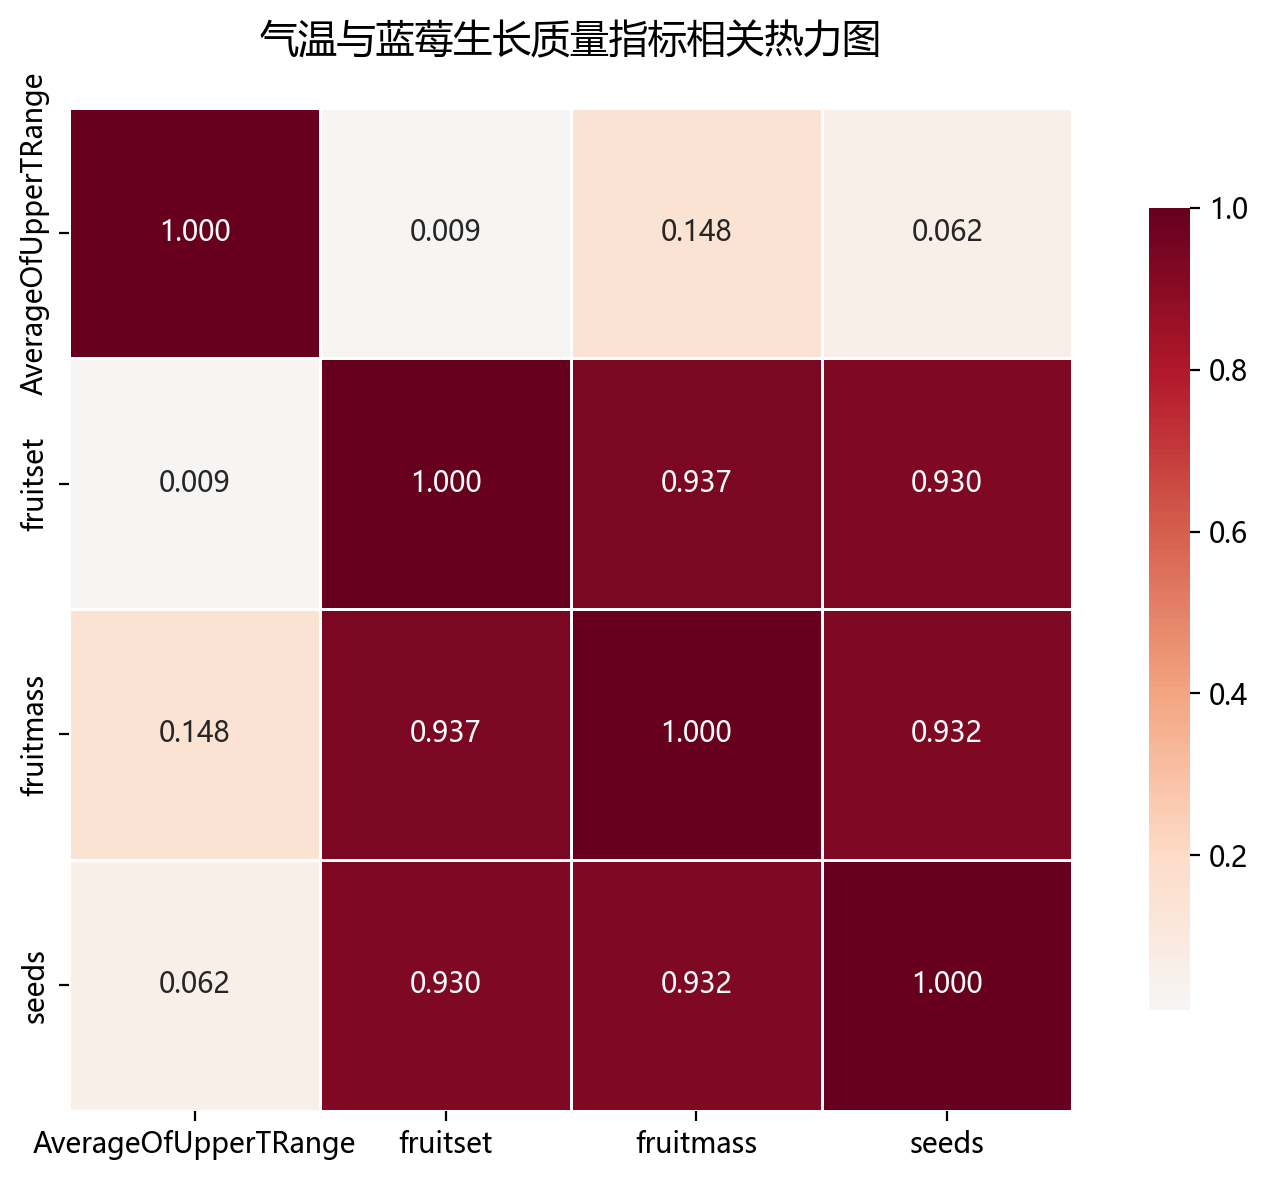

In [14]:
# 绘制热力图 局部
plt.figure(figsize=(8,6),dpi=200)
sns.heatmap(growth_corr,
            annot=True,  # 显示数值标签
            fmt='.3f', # 数值格式：保留3位小数
            cmap='RdBu_r', # 颜色映射：红蓝渐变（红为正相关，蓝为负相关）
            center=0, # 颜色中心点为0（白色表示无相关）
            square=True, # 每个单元格为正方形
            linewidths=1, # 单元格之间的分隔线宽度
            cbar_kws={'shrink':0.8})  # 颜色条缩放为原来的80%
plt.title('气温与蓝莓生长质量指标相关热力图',fontsize=14,pad=20)
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

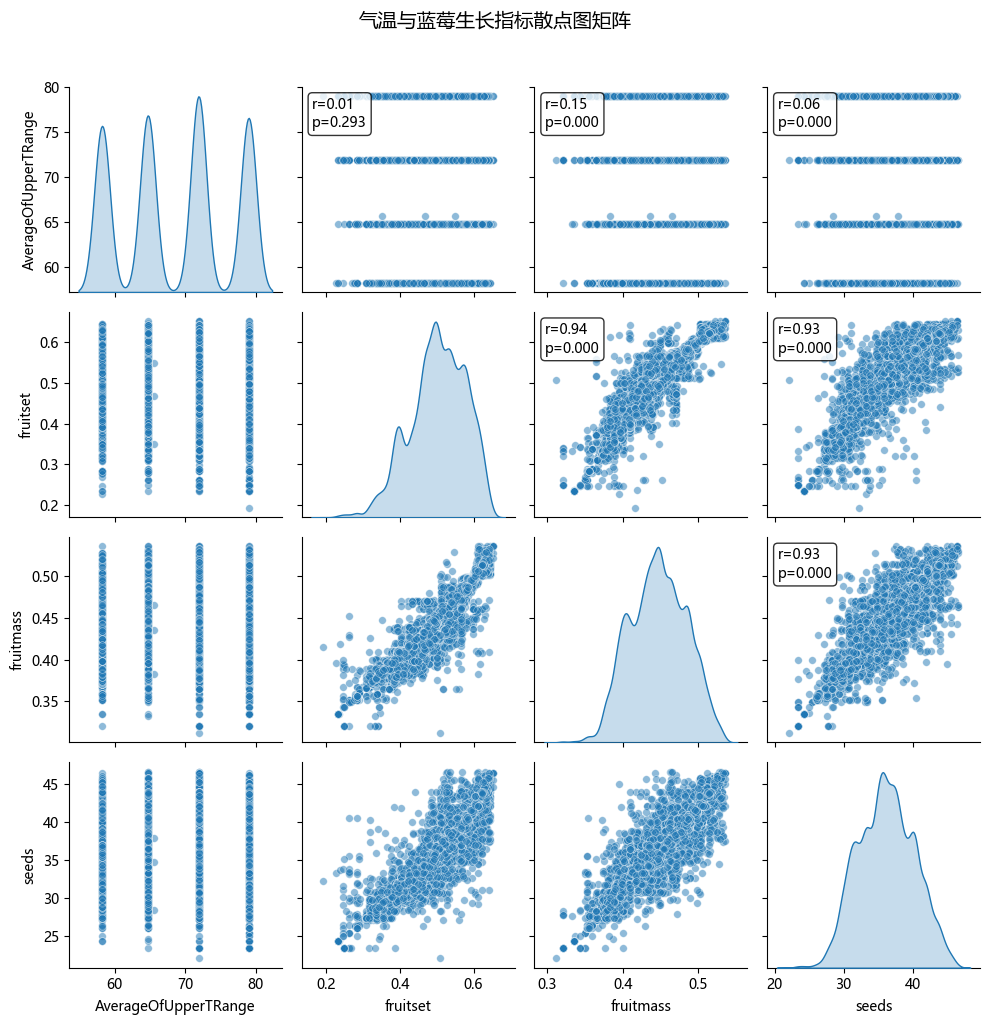

In [46]:
# 使用pairplot绘制变量间的成对关系矩阵，是对相关性的更全面可视化
fig=plt.figure(figsize=(12,10))
g=sns.pairplot(df_train[growth_vars],
               diag_kind='kde', # 对角线显示核密度估计图,对应每个变量自身的分布情况
               plot_kws={'alpha':0.5,'s':30}, # 散点图参数：透明度0.5，点大小30；非对角线图 (散点图)显示两个变量之间的关系
               diag_kws={'fill':True}) # 密度图填充

# 添加相关系数标注
def add_corr_annot():
    # 获取上三角部分的位置,只处理上三角，上三角与下三角是对称的
    axes = g.axes
    for i in range(len(growth_vars)):
        for j in range(i+1,len(growth_vars)):
            var1=growth_vars[i]
            var2=growth_vars[j]
            corr=df_train[var1].corr(df_train[var2])
            p_value=pearsonr(df_train[var1], df_train[var2])[1]

            # 添加文本到对应子图
            ax=axes[i,j]
            text=f'r={corr:.2f}\np={p_value:.3f}'
            ax.text(0.05,0.95,text, # 在子图的 (5%, 95%) 位置（左上角附近）添加text内的内容
                    transform=ax.transAxes, #使用相对坐标（0-1之间），不管子图大小，位置始终在左上角
                    fontsize=10, #字体大小
                    verticalalignment='top', #文本顶部对齐到指定 y 坐标
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)) #添加白色半透明背景框，更易阅读

add_corr_annot()

plt.suptitle('气温与蓝莓生长指标散点图矩阵', y=1.02, fontsize=14)

plt.savefig('气温与蓝莓生长指标散点图矩阵.png',dpi=1200,bbox_inches='tight')

plt.tight_layout()
plt.show()

In [16]:
df_train.head()

,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield,size_group
0,25.0,0.50,0.25,0.75,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146,中
1,25.0,0.50,0.25,0.50,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201,中
2,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760,小
3,12.5,0.25,0.25,0.63,0.50,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590,小
4,25.0,0.50,0.25,0.63,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417,中


##降雨对蓝莓生长的影响分析

--------------------------------------------------
分析指标：RainingDays
--------------------------------------------------
返回每个组的描述性统计信息
RainingDays 分组统计：
rain_group
少雨    7930
正常    3837
多雨    3522
Name: count, dtype: int64

各组降雨范围:
             min   max       mean  count
rain_group                              
少雨           1.0  16.0   9.265821   7930
正常          24.0  24.0  24.000000   3837
多雨          26.0  34.0  33.997729   3522

不同降水等级下的生长指标
            fruitset  fruitmass      seeds
rain_group                                
少雨          0.534542   0.461690  37.921273
正常          0.484410   0.437171  35.078082
多雨          0.451108   0.422691  33.394556


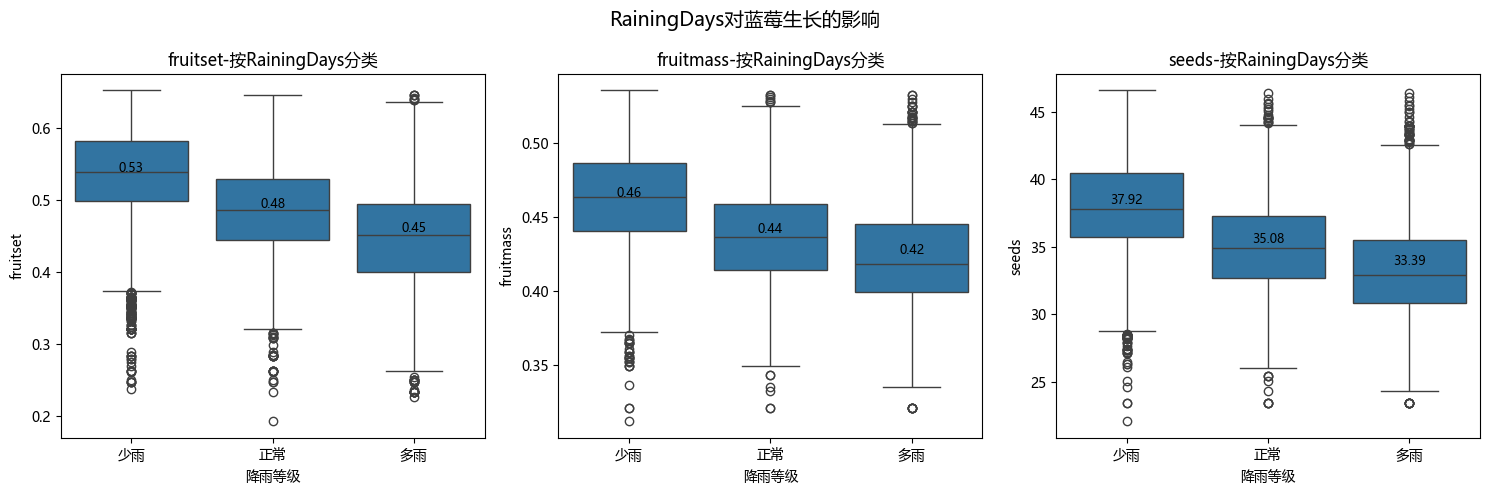


统计检验结果（ANOVA）:
  fruitset: F=2168.548, p=0.0000 ✓ 显著差异
  fruitmass: F=1891.650, p=0.0000 ✓ 显著差异
  seeds: F=2225.603, p=0.0000 ✓ 显著差异
--------------------------------------------------
分析指标：AverageRainingDays
--------------------------------------------------
返回每个组的描述性统计信息
AverageRainingDays 分组统计：
rain_group
少雨    7933
正常    3837
多雨    3519
Name: count, dtype: int64

各组降雨范围:
             min   max     mean  count
rain_group                            
少雨          0.06  0.26  0.18773   7933
正常          0.39  0.39  0.39000   3837
多雨          0.56  0.56  0.56000   3519

不同降水等级下的生长指标
            fruitset  fruitmass      seeds
rain_group                                
少雨          0.534475   0.461661  37.918142
正常          0.484446   0.437188  35.079731
多雨          0.451150   0.422704  33.395959


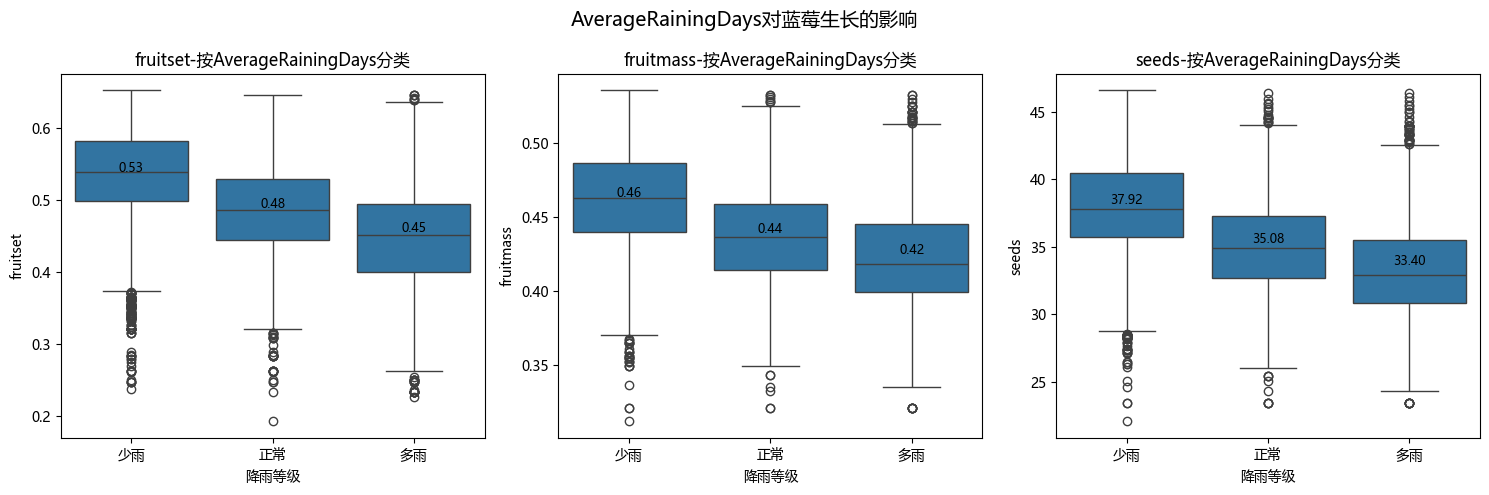


统计检验结果（ANOVA）:
  fruitset: F=2159.748, p=0.0000 ✓ 显著差异
  fruitmass: F=1885.127, p=0.0000 ✓ 显著差异
  seeds: F=2218.323, p=0.0000 ✓ 显著差异


In [49]:
# 降雨量分级分析
import warnings
warnings.filterwarnings('ignore') #忽略警告

def categorize_rainfall(df,rain_var='RainingDays'):
    """
    分组函数，将降雨量分为三个等级：少雨、正常、多雨
    """
    df_rain=df_train.copy()

    df_rain['rain_group']=pd.qcut(df_rain[rain_var],q=3,labels=['少雨','正常','多雨'],duplicates='drop')

    # 查看分组统计
    print(f"{rain_var} 分组统计：")
    print(df_rain['rain_group'].value_counts())
    print("\n各组降雨范围:")
    print(df_rain.groupby('rain_group')[rain_var].agg(['min','max','mean','count']))

    return df_rain

rain_vars=['RainingDays','AverageRainingDays']

# 第一层循环依次输入rain_vars对生长指标的影响
for var in rain_vars:
    print('-'*50)
    print(f"分析指标：{var}")
    print('-'*50)

    # 按对应的反映雨天的变量来分3个组，会返回每个组的描述性统计信息
    print('返回每个组的描述性统计信息')
    df_rain_grouped=categorize_rainfall(df_train,var)

    # 计算各组生长指标均值
    print('\n不同降水等级下的生长指标')
    # 按降雨等级分组来统计'fruitset','fruitmass','seeds'三个蓝莓质量指标的平均值
    growth_means=df_rain_grouped.groupby('rain_group')[['fruitset','fruitmass','seeds']].mean()
    print(growth_means)

    # 绘制箱线图
    fig,axes=plt.subplots(1,3,figsize=(15,5))
    
    # 箱型图内的循环表示按不同的质量指标生成子图
    for i,growth_var in enumerate(['fruitset','fruitmass','seeds']):
        sns.boxplot(x='rain_group',
                    y=growth_var,
                    data=df_rain_grouped,
                    order=['少雨', '正常', '多雨'],
                    ax=axes[i])
        axes[i].set_title(f"{growth_var}-按{var}分类")
        axes[i].set_xlabel('降雨等级')
        axes[i].set_ylabel(growth_var)

        means = df_rain_grouped.groupby('rain_group')[growth_var].mean()
        # 这个循环是用于显示每个子图内每个组的对应质量指标的均值
        for j,group in enumerate(['少雨', '正常', '多雨']):
            axes[i].text(j,means[group],f'{means[group]:.2f}',ha='center',va='bottom',fontsize=9)

    plt.suptitle(f'{var}对蓝莓生长的影响', fontsize=14)

    plt.savefig(f'{var}降雨量分级对蓝莓质量指标的影响.png',dpi=600,bbox_inches='tight')
    plt.tight_layout()
    plt.show()

    # 统计检验
    print("\n统计检验结果（ANOVA）:")
    for growth_var in ['fruitset', 'fruitmass', 'seeds']:
        # 列表推导式,先用g遍历3个下雨等级，
        groups = [df_rain_grouped[df_rain_grouped['rain_group']==g][growth_var] for g in ['少雨', '正常', '多雨']]
        f_stat, p_value = f_oneway(*groups)
        if p_value < 0.05:
            print(f"  {growth_var}: F={f_stat:.3f}, p={p_value:.4f} ✓ 显著差异")
        else:
            print(f"  {growth_var}: F={f_stat:.3f}, p={p_value:.4f} ✗ 无显著差异")

In [18]:
df_train.head()

,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield,size_group
0,25.0,0.50,0.25,0.75,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146,中
1,25.0,0.50,0.25,0.50,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201,中
2,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760,小
3,12.5,0.25,0.25,0.63,0.50,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590,小
4,25.0,0.50,0.25,0.63,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417,中



--------------------------------------------------
极端讲述情况分析-RainingDays
--------------------------------------------------

极端情况定义:
极多雨：RainingDays>=34.00
极少雨：RainingDays<=1.00
正常范围：34.00>RainingDays>1.00

每个分类样本数
rain_category
正常     8247
极多雨    3521
极少雨    3521
Name: count, dtype: int64

 不同降雨情况生长指标均值
               fruitset  fruitmass      seeds
rain_category                                
极多雨            0.451117   0.422691  33.394721
极少雨            0.547947   0.468529  38.749249
正常             0.505481   0.447358  36.244332

极端情况对生长指标的影响

极少雨情况
fruitset:增加8.4%
--------------------------------------------------
fruitmass:增加4.7%
--------------------------------------------------
seeds:增加6.9%
--------------------------------------------------

极多雨情况
fruitset:减少10.8%
--------------------------------------------------
fruitmass:减少5.5%
--------------------------------------------------
seeds:减少7.9%
--------------------------------------------------


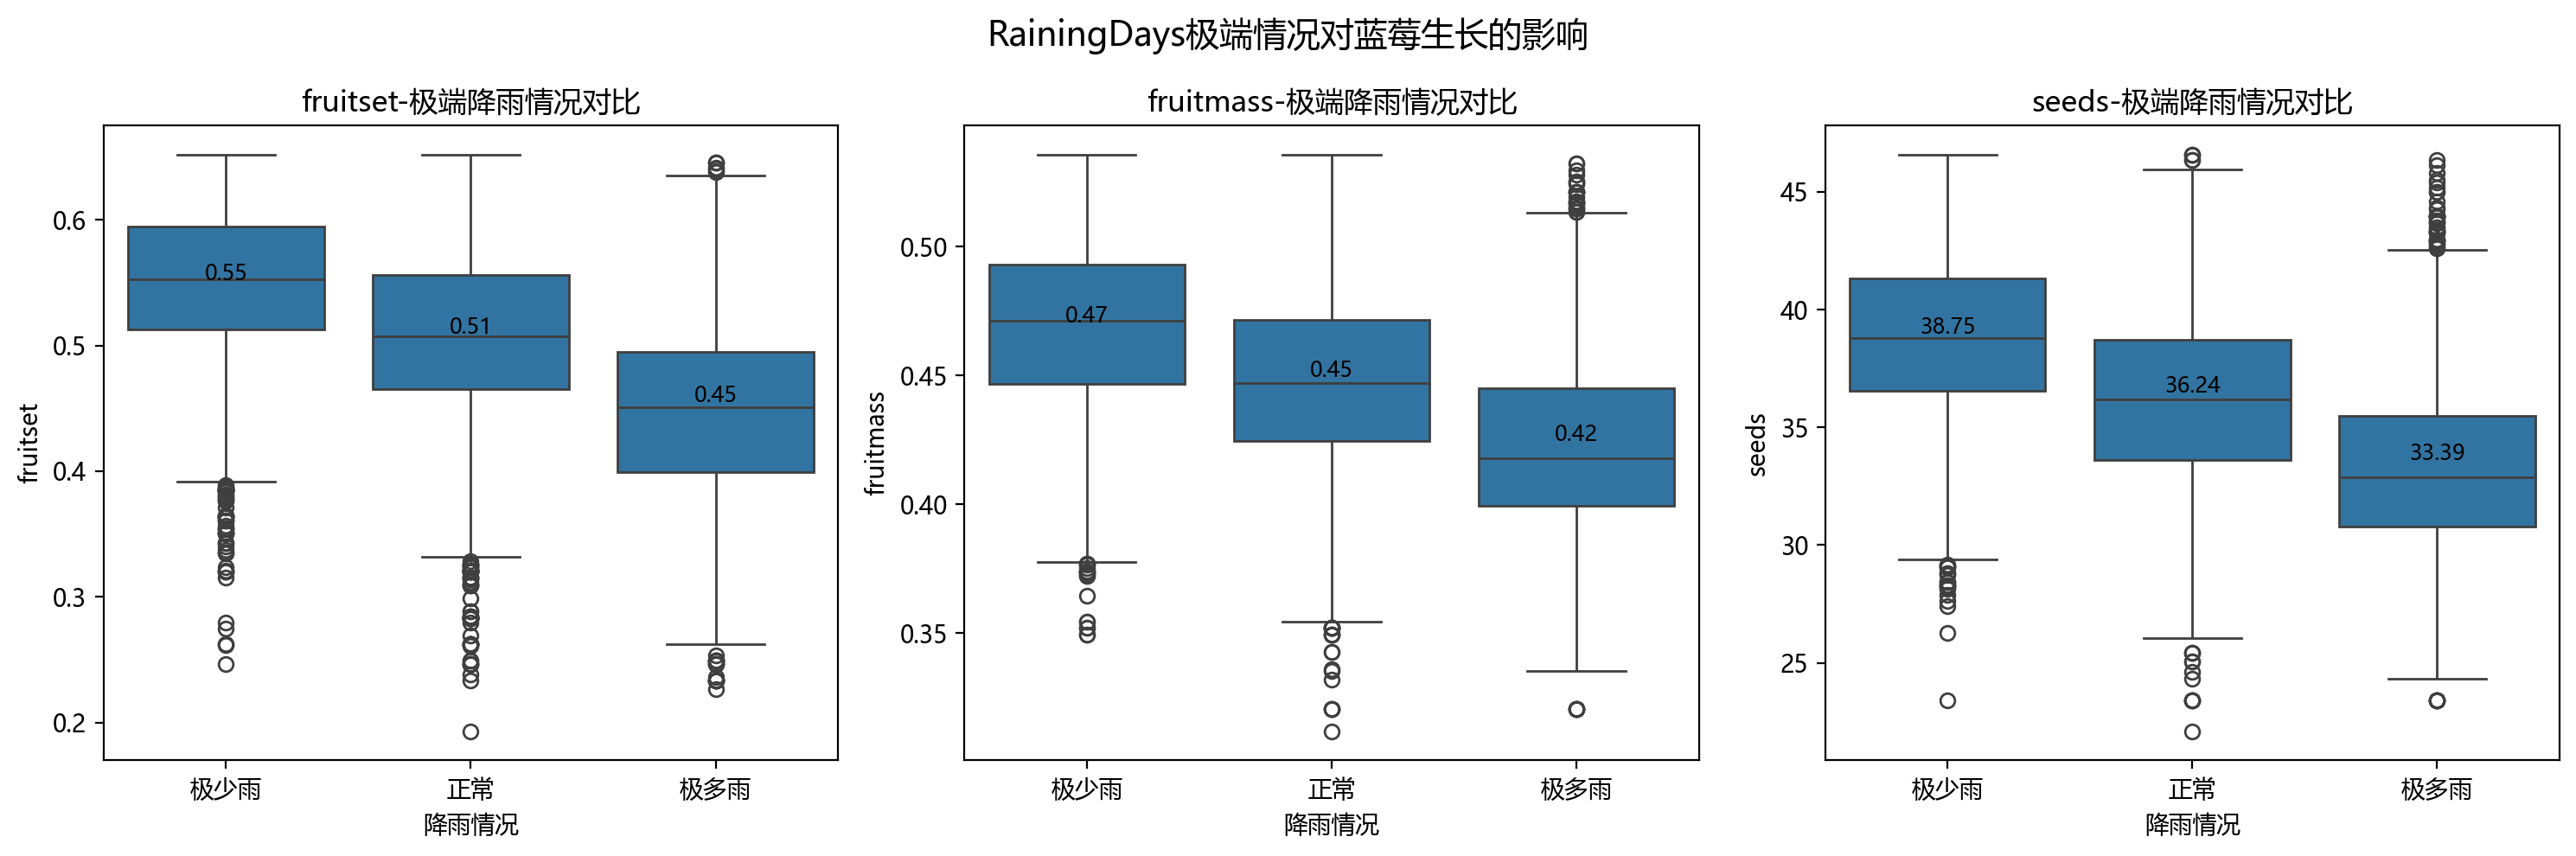


统计结果（极端组 vs 正常组）

极少雨组 vs 正常组
fruitset:t=32.369,p=0.000 差异显著
fruitmass:t=31.277,p=0.000 差异显著
seeds:t=34.466,p=0.000 差异显著

极多雨组 vs 正常组
fruitset:t=-39.353,p=0.000 差异显著
fruitmass:t=-36.345,p=0.000 差异显著
seeds:t=-39.194,p=0.000 差异显著

--------------------------------------------------
极端讲述情况分析-AverageRainingDays
--------------------------------------------------

极端情况定义:
极多雨：AverageRainingDays>=0.56
极少雨：AverageRainingDays<=0.10
正常范围：0.56>AverageRainingDays>0.10

每个分类样本数
rain_category
正常     8200
极少雨    3570
极多雨    3519
Name: count, dtype: int64

 不同降雨情况生长指标均值
               fruitset  fruitmass      seeds
rain_category                                
极多雨            0.451150   0.422704  33.395959
极少雨            0.546825   0.467943  38.675520
正常             0.505688   0.447474  36.260237

极端情况对生长指标的影响

极少雨情况
fruitset:增加8.1%
--------------------------------------------------
fruitmass:增加4.6%
--------------------------------------------------
seeds:增加6.7%
----------------------------------------

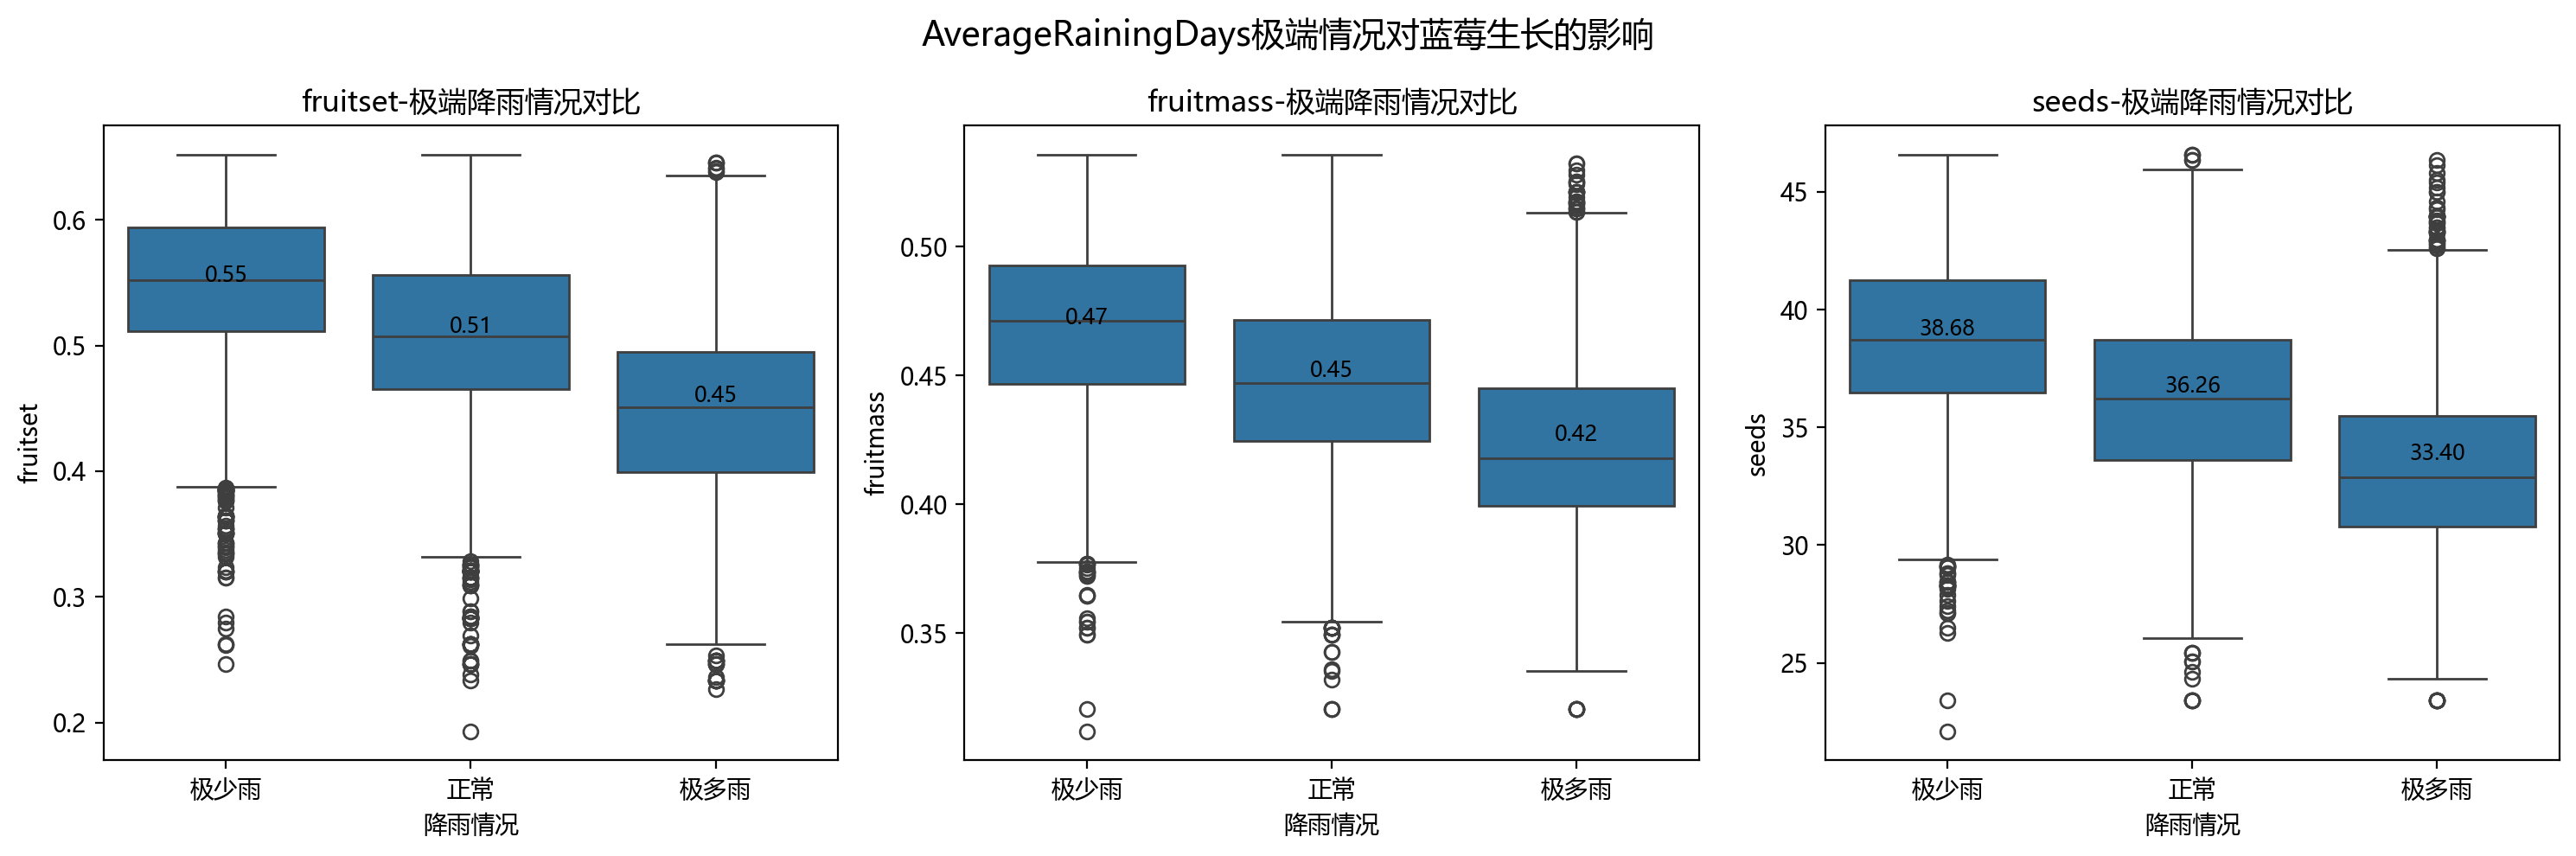


统计结果（极端组 vs 正常组）

极少雨组 vs 正常组
fruitset:t=31.397,p=0.000 差异显著
fruitmass:t=30.282,p=0.000 差异显著
seeds:t=33.255,p=0.000 差异显著

极多雨组 vs 正常组
fruitset:t=-39.501,p=0.000 差异显著
fruitmass:t=-36.537,p=0.000 差异显著
seeds:t=-39.464,p=0.000 差异显著


In [50]:
# 极端降水情况分析

def extreme_rainfall(df,rain_var='RainingDays'):
    '''
    分析极端降雨情况对蓝莓生长的影响
    '''
    print('\n'+'-'*50)
    print(f'极端讲述情况分析-{rain_var}')
    print('-'*50)
    
    # 复制一份df_train用作极端降雨情况分析
    df_extreme=df_train.copy()

    #定义极端情况的临界水平(头尾的10%)
    lower_threshold=df_extreme[rain_var].quantile(0.1)
    upper_threshold=df_extreme[rain_var].quantile(0.9)

    #先全部设为正常，再把异常值覆盖修改
    df_extreme['rain_category']='正常'
    df_extreme.loc[df_extreme[rain_var]<=lower_threshold,'rain_category']='极少雨'
    df_extreme.loc[df_extreme[rain_var]>=upper_threshold,'rain_category']='极多雨'

    print('\n极端情况定义:')
    print(f'极多雨：{rain_var}>={upper_threshold:.2f}')
    print(f'极少雨：{rain_var}<={lower_threshold:.2f}')
    print(f'正常范围：{upper_threshold:.2f}>{rain_var}>{lower_threshold:.2f}')

    print('\n每个分类样本数')
    print(df_extreme['rain_category'].value_counts())

    # 对比不同降雨情况下的生长指标
    print('\n 不同降雨情况生长指标均值')
    extreme_comparison=df_extreme.groupby('rain_category')[['fruitset','fruitmass','seeds']].mean()
    print(extreme_comparison)

    # 计算极端情况的影响程度
    print('\n极端情况对生长指标的影响')
    normal_mean=df_extreme[df_extreme['rain_category']=='正常'][['fruitset','fruitmass','seeds']].mean()

    for category in ['极少雨','极多雨']:
        print(f"\n{category}情况")
        category_mean=df_extreme[df_extreme['rain_category']==category][['fruitset','fruitmass','seeds']].mean()

        for growth_var in ['fruitset','fruitmass','seeds']:
            # 计算变化率
            change_pct=(category_mean[growth_var]-normal_mean[growth_var])*100/normal_mean[growth_var]
            # 判断变化方向
            direction= '增加' if change_pct>0 else '减少'
            print(f'{growth_var}:{direction}{abs(change_pct):.1f}%')
            print('-'*50)

    # 绘制极端情况图
    fig,axes=plt.subplots(1,3,figsize=(15,5),dpi=200)
    for i,growth_var in enumerate(['fruitset','fruitmass','seeds']):
        #箱型图
        sns.boxplot(x='rain_category',y=growth_var,data=df_extreme,
                    order=['极少雨','正常','极多雨'],ax=axes[i])
        axes[i].set_title(f'{growth_var}-极端降雨情况对比')
        axes[i].set_xlabel('降雨情况')
        axes[i].set_ylabel(f'{growth_var}')

        #添加均值标注
        means=df_extreme.groupby('rain_category')[growth_var].mean()
        for j,cat in enumerate(['极少雨','正常','极多雨']):
            if cat in means.index:
                axes[i].text(j,means[cat],f'{means[cat]:.2f}',ha='center',va='bottom',fontsize=9)

    plt.suptitle(f'{rain_var}极端情况对蓝莓生长的影响',fontsize=14)
    plt.savefig(f'{rain_var}极端情况对蓝莓生长的影响',dpi=600,bbox_inches='tight')
    plt.tight_layout()
    plt.show()

    # 统计检验（极端组 vs 正常组）
    print('\n统计结果（极端组 vs 正常组）')
    normal_group=df_extreme[df_extreme['rain_category']=='正常']

    for category in ['极少雨','极多雨']:
        print(f'\n{category}组 vs 正常组')
        extreme_group=df_extreme[df_extreme['rain_category']==category]

        for growth_var in ['fruitset','fruitmass','seeds']:
            # 不同降雨情况组的同一个质量参数，用t检验来统计
            from scipy.stats import ttest_ind
            t_stat,p_value=ttest_ind(extreme_group[growth_var],normal_group[growth_var])

            # 置信度还是设置为0.05
            if p_value<0.05:
                print(f'{growth_var}:t={t_stat:.3f},p={p_value:.3f} 差异显著')
            else:
                print(f'{growth_var}:t={t_stat:.3f},p={p_value:.3f} 差异不显著')

    print("="*80)
    print('='*80)
    return df_extreme

rain_vars=['RainingDays','AverageRainingDays']

for rain_var in rain_vars:
    df_extreme=extreme_rainfall(df_train,rain_var)    

##机器学习预测模型

In [20]:
df_val=pd.read_csv('./test.csv')

df_val.head()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds
0,15289,25.0,0.25,0.25,0.25,0.25,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.399367,0.408088,31.394569
1,15290,12.5,0.25,0.25,0.75,0.63,94.6,57.2,79.0,68.2,33.0,55.9,1.0,0.10,0.488048,0.442866,36.846956
2,15291,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.583379,0.487057,40.037644
3,15292,25.0,0.50,0.38,0.38,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.433014,0.422847,33.116091
4,15293,37.5,0.75,0.25,0.25,0.25,94.6,57.2,79.0,68.2,33.0,55.9,24.0,0.39,0.360996,0.388860,29.558019


In [21]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10194 non-null  int64  
 1   clonesize             10194 non-null  float64
 2   honeybee              10194 non-null  float64
 3   bumbles               10194 non-null  float64
 4   andrena               10194 non-null  float64
 5   osmia                 10194 non-null  float64
 6   MaxOfUpperTRange      10194 non-null  float64
 7   MinOfUpperTRange      10194 non-null  float64
 8   AverageOfUpperTRange  10194 non-null  float64
 9   MaxOfLowerTRange      10194 non-null  float64
 10  MinOfLowerTRange      10194 non-null  float64
 11  AverageOfLowerTRange  10194 non-null  float64
 12  RainingDays           10194 non-null  float64
 13  AverageRainingDays    10194 non-null  float64
 14  fruitset              10194 non-null  float64
 15  fruitmass          

In [22]:
!pip install xgboost

In [23]:
!pip install lightgbm joblib

In [24]:
# 导入库
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import joblib

In [25]:
# 检查验证集的缺失值
print('\n验证集缺失值')
print(df_val.isnull().sum())


验证集缺失值
id                      0
clonesize               0
honeybee                0
bumbles                 0
andrena                 0
osmia                   0
MaxOfUpperTRange        0
MinOfUpperTRange        0
AverageOfUpperTRange    0
MaxOfLowerTRange        0
MinOfLowerTRange        0
AverageOfLowerTRange    0
RainingDays             0
AverageRainingDays      0
fruitset                0
fruitmass               0
seeds                   0
dtype: int64


#特征工程
特征工程 = 把原始数据 → 加工成模型能看懂、效果更好的 “特征”

In [26]:
# 删除冗余的特征
df_feature=df_train.drop(['MaxOfUpperTRange','MinOfUpperTRange','MaxOfLowerTRange','MinOfLowerTRange','size_group'],axis=1)

# 缺失值之前以及查询了，没有，所以不用进行缺失值填充

df_feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15289 entries, 0 to 15288
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   clonesize             15289 non-null  float64
 1   honeybee              15289 non-null  float64
 2   bumbles               15289 non-null  float64
 3   andrena               15289 non-null  float64
 4   osmia                 15289 non-null  float64
 5   AverageOfUpperTRange  15289 non-null  float64
 6   AverageOfLowerTRange  15289 non-null  float64
 7   RainingDays           15289 non-null  float64
 8   AverageRainingDays    15289 non-null  float64
 9   fruitset              15289 non-null  float64
 10  fruitmass             15289 non-null  float64
 11  seeds                 15289 non-null  float64
 12  yield                 15289 non-null  float64
dtypes: float64(13)
memory usage: 1.5 MB



异常值检测结果（IQR方法）:
honeybee            |异常值数  8,0.05%|范围：(-0.12,0.88)
bumbles             |异常值数 10,0.07%|范围：(0.05,0.57)
andrena             |异常值数  8,0.05%|范围：(0.01,1.00)
osmia               |异常值数 56,0.37%|范围：(0.12,1.12)
RainingDays         |异常值数3569,23.34%|范围：(4.00,36.00)
AverageRainingDays  |异常值数 49,0.32%|范围：(0.07,0.58)
fruitset            |异常值数 97,0.63%|范围：(0.30,0.71)
fruitmass           |异常值数 23,0.15%|范围：(0.34,0.56)
seeds               |异常值数 24,0.16%|范围：(24.34,48.05)


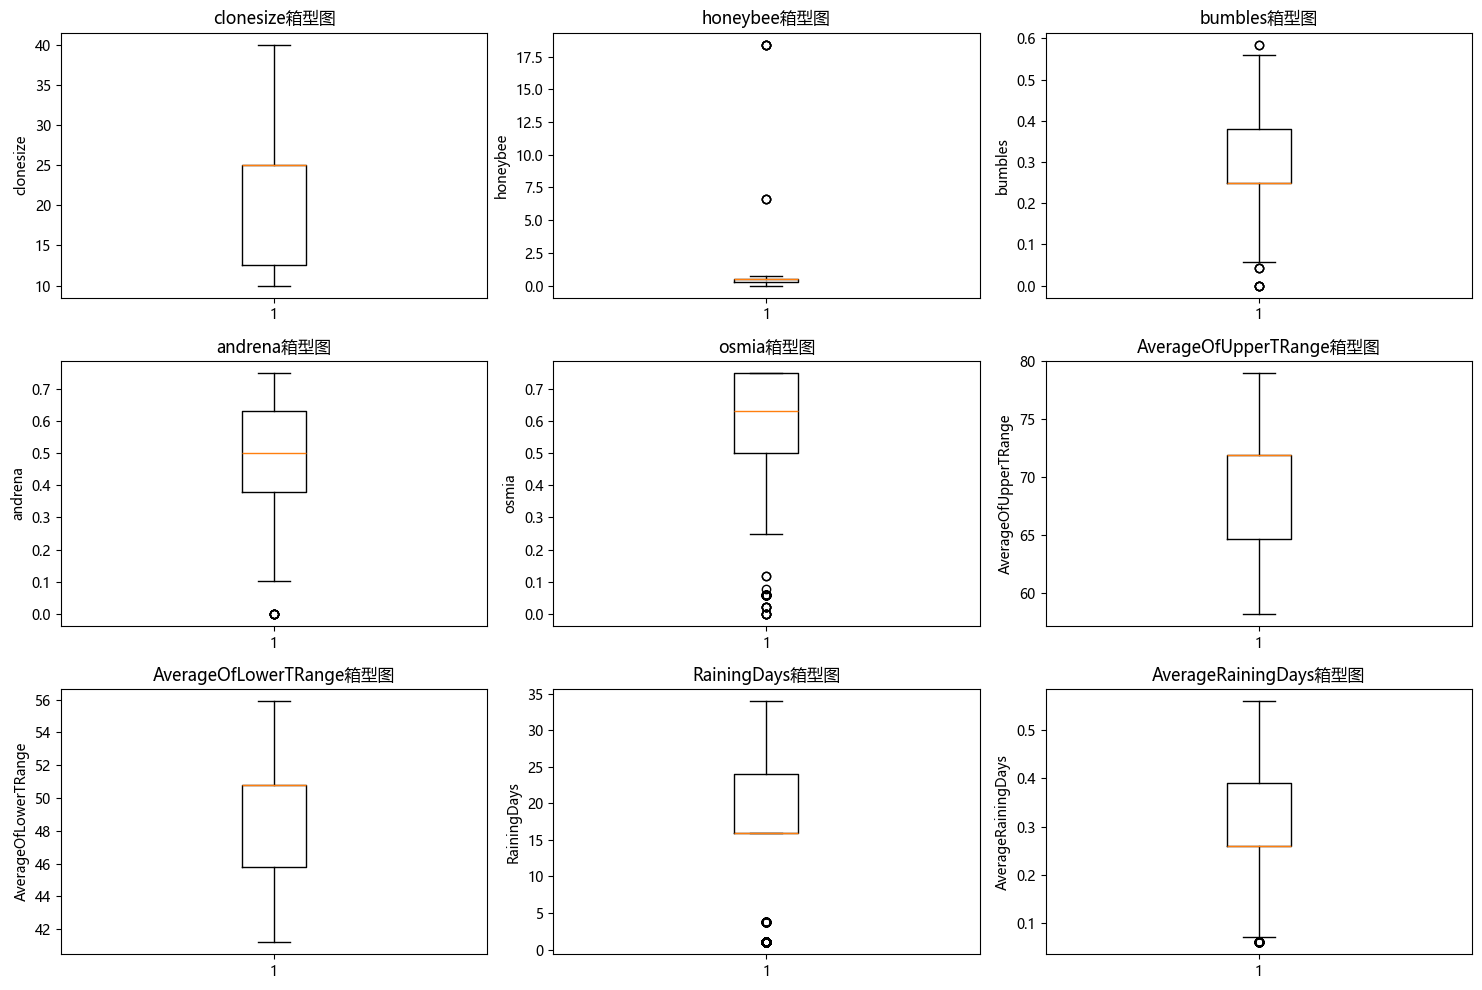

In [51]:
# 异常值处理
# 定义使用IQR方法检测异常值的函数
def detect_outliers_iqr(df,column):
    """使用IQR方法检测异常值"""
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    outliers=df[(df[column]<lower_bound) | (df[column]>upper_bound)]
    return outliers,lower_bound,upper_bound

# 定义用Z-score检测异常值的函数
from scipy import stats
def detect_outliers_zscore(df,column,threshold=3):
    """使用Z-score方法检测异常值"""
    z_scores=np.abs(stats.zscore(df[column].dropna()))
    outliers=df[z_score>threshold]
    return outliers

# 检查各特征的异常值
print("\n异常值检测结果（IQR方法）:")
outlier_summary={}

# 遍历df_feature中的数值字段
for col in df_feature.select_dtypes(include=[np.number]).columns:
    if col != 'yield':  # 不对目标变量做异常值处理
        outliers,lb,ub=detect_outliers_iqr(df_feature,col)
        outlier_count=len(outliers)
        outlier_pct=(outlier_count*100/len(df_feature))

        outlier_summary[col]={
            'count':outlier_count,
            'percentage':outlier_pct,
            'lower_bound':lb,
            'upper_bound':ub
        }

        if outlier_count>0:
            print(f"{col:20}|异常值数{outlier_count:3},{outlier_pct:.2f}%|"
                  f"范围：({lb:.2f},{ub:.2f})")

# 异常值可视化,只展示前6列
fig,axes=plt.subplots(3,3,figsize=(15,10))
axes=axes.flatten() #展开二维轴成一维

for idx,col in enumerate(df_feature.select_dtypes(include=[np.number]).columns[:9]):
    if col != 'yield':
        axes[idx].boxplot(df_feature[col]) # 每个子图做一个箱型图
        axes[idx].set_title(f"{col}箱型图",fontsize=12)
        axes[idx].set_ylabel(col)

plt.savefig('各个字段异常值分布.png',dpi=600,bbox_inches='tight')
plt.tight_layout()
plt.show()

In [28]:
# 处理异常值
# 报告发现RainingDays的分布是两头分布，不均匀，所以不用RainingDays，改为选用更均匀的AverageRainingDays

def cap_outliers(df,columns):
    # 跳过 RainingDays，不处理它的异常值
    df_clean=df.copy()
    outliers_before_count=0
    outliers_after_count=0
    
    for col in columns:
        if col=='RainingDays':
            continue
        outliers_before,_,_=detect_outliers_iqr(df_clean,col)
        outliers_before_count=outliers_before_count+len(outliers_before)
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lb = Q1 - 1.5 * IQR
        ub = Q3 + 1.5 * IQR   

        # 温和处理，采用截断，把超出正常范围的值把改成边界值
        # 数据清洗优先用 clip()，避免样本丢失导致模型 / 分析偏差
        df_clean[col]=df_clean[col].clip(lb,ub)

        outliers_after,_,_=detect_outliers_iqr(df_clean, col)
        outliers_after_count=outliers_after_count+len(outliers_after)

    print(f"处理前异常值总数: {outliers_before_count}")
    print(f"处理后异常值总数: {outliers_after_count}")
    print(f"处理了 {outliers_before_count - outliers_after_count} 个异常值")

    return df_clean

cols=['clonesize','honeybee','bumbles', 
      'andrena','osmia','AverageOfUpperTRange',
      'AverageOfLowerTRange','RainingDays',
      'AverageRainingDays','fruitset','fruitmass','seeds']

df_clean=cap_outliers(df_feature,cols)

处理前异常值总数: 275
处理后异常值总数: 0
处理了 275 个异常值


In [29]:
df_clean.head()

,clonesize,honeybee,bumbles,andrena,osmia,AverageOfUpperTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
0,25.0,0.50,0.25,0.75,0.50,58.2,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146
1,25.0,0.50,0.25,0.50,0.50,58.2,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201
2,12.5,0.25,0.25,0.63,0.63,71.9,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760
3,12.5,0.25,0.25,0.63,0.50,64.7,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590
4,25.0,0.50,0.25,0.63,0.63,64.7,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417


In [30]:
# 创建强特征

# 总授粉蜂量,考虑不同蜜蜂对蓝莓的授粉效率差异，简单模拟，设置权重
# 熊蜂 (Bumbles)	1.0-1.2	最有效率，能振动授粉（buzz pollination），低温阴雨天也能工作 设置权重为1.1
# 壁蜂 (Osmia)	    0.9-1.1	蓝莓壁蜂专门为蓝莓授粉，效率很高 设置权重为1
# 地蜂 (Andrena)	0.7-0.9	重要野生传粉者，但活动时间有限 设置权重为0.8
# 蜜蜂 (Honeybee)	0.5-0.7	不特别喜欢蓝莓花，容易飞走寻找更喜欢的蜜源 设置权重为0.6
df_clean['total_bees']=df_clean['honeybee']*0.6+df_clean['bumbles']*1.1+df_clean['andrena']*0.8+df_clean['osmia']*1

# 果实综合指数，三个指标相乘，反映整体果实表现
df_clean['fruit_composite']=df_clean['fruitset']*df_clean['seeds']*df_clean['fruitmass']
# df_clean['mass_per_seed'] = df_clean['fruitmass'] / (df_clean['seeds'] + 1e-8) 单粒种子质量：反映种子饱满度，果实品质的重要指标

# 环境压力特征 温度+雨水，标准化压力指数，Z-score 标准化 Z = (x - 均值) /标准差
df_clean['temp_norm']=(df_clean['AverageOfUpperTRange']-df_clean['AverageOfUpperTRange'].mean())/df_clean['AverageOfUpperTRange'].std()
df_clean['rain_norm']=(df_clean['AverageRainingDays']-df_clean['AverageRainingDays'].mean())/df_clean['AverageRainingDays'].std()
df_clean['stress'] = df_clean['temp_norm']*df_clean['rain_norm']

In [31]:
df_clean.head()

,clonesize,honeybee,bumbles,andrena,osmia,AverageOfUpperTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield,total_bees,fruit_composite,temp_norm,rain_norm,stress
0,25.0,0.50,0.25,0.75,0.50,58.2,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146,1.675,5.760553,-1.368296,0.401563,-0.549457
1,25.0,0.50,0.25,0.50,0.50,58.2,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201,1.475,6.357717,-1.368296,0.401563,-0.549457
2,12.5,0.25,0.25,0.63,0.63,71.9,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760,1.559,9.982175,0.424473,0.401563,0.170453
3,12.5,0.25,0.25,0.63,0.50,64.7,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590,1.429,10.680476,-0.517712,0.401563,-0.207894
4,25.0,0.50,0.25,0.63,0.63,64.7,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417,1.709,11.597022,-0.517712,0.401563,-0.207894


In [ ]:
from


1. 准备数据...
特征数量：10
样本数量：15289

2.处理分类变量...

3.处理缺失值...
无缺失值

4.划分训练集和验证集
训练集：(12231, 10)
验证集：(3058, 10)

5.数值特征标准化
标准化完成

6.训练模型...
模型训练完成

7.模型评估...
\n训练集$R^2$= 0.9731
验证集 R²:0.8120
验证集 RMSE:574.8098
验证集 MAE:363.4406

8.可视化结果


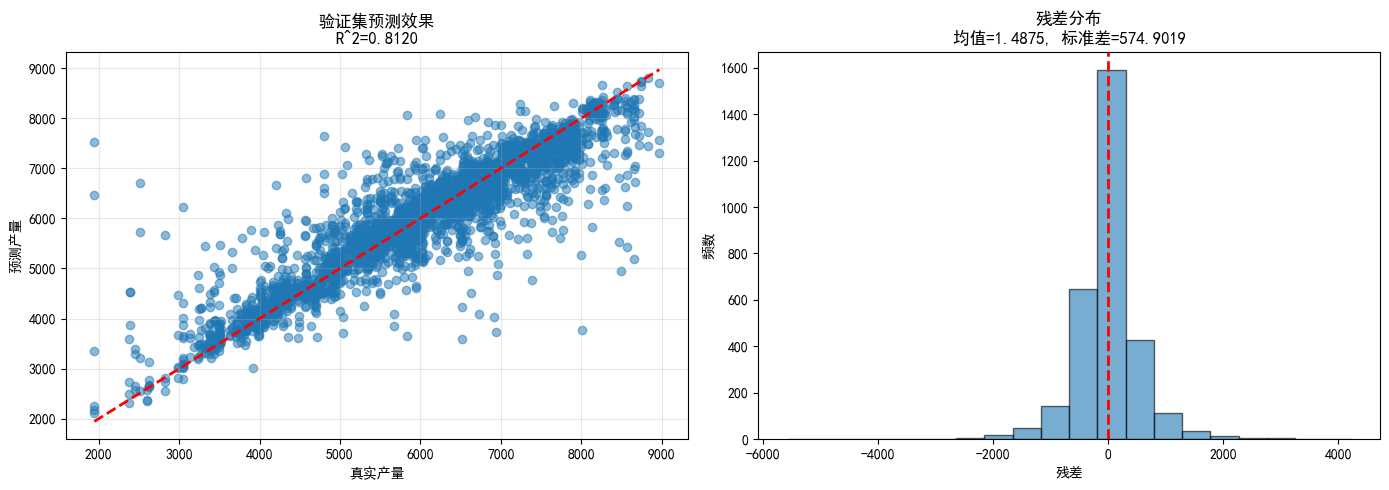


9.特征重要性分析...


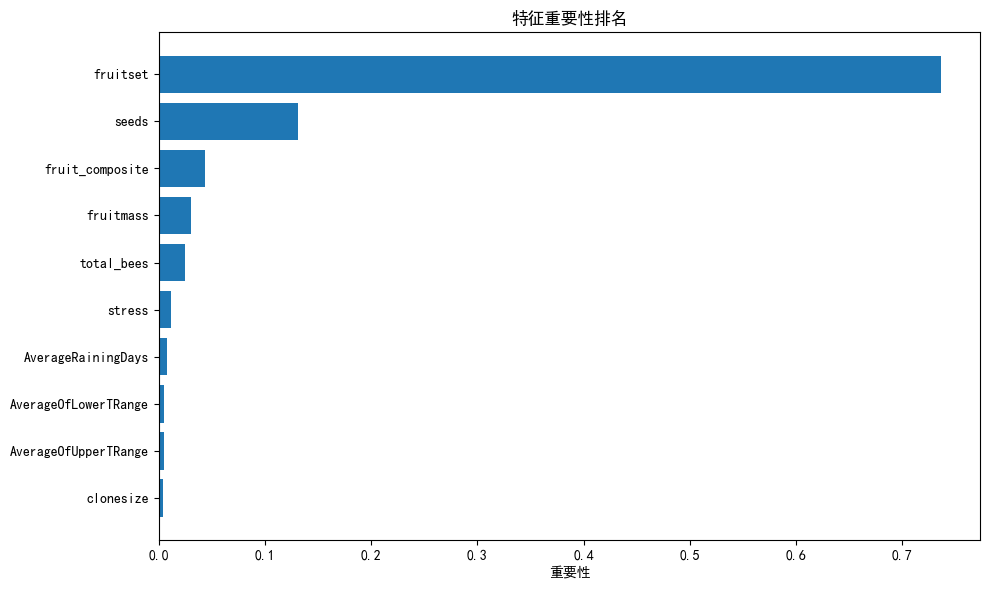

In [52]:
# 特征选择
print("\n1. 准备数据...")
best_features = ['clonesize','total_bees','AverageOfUpperTRange',
                 'AverageOfLowerTRange','AverageRainingDays','fruitset',
                 'fruitmass','seeds','fruit_composite','stress']

X=df_clean[best_features].copy() #显式复制一份，避免df_clean被修改，后续对 X 的任何增删改，都不会传播回原 df_clean
y=df_clean['yield'].copy()
print(f'特征数量：{X.shape[1]}')
print(f'样本数量：{X.shape[0]}')

# 2.处理分类变量 本数据集没有分类变量
print("\n2.处理分类变量...")

# 3.处理缺失值 缺失值已在先前检查过，目前英爱没有缺失值
print("\n3.处理缺失值...")
if X.isnull().sum().sum()>0: #两个sum汇总整个表有多少缺失值,一个sum汇总每一列的缺失值
    print(f'存在缺失值，用中位数填充')
    X=x.fillna(X.median())
else:
    print('无缺失值')

# 4.划分训练集和验证集
print('\n4.划分训练集和验证集')
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)
print(f'训练集：{X_train.shape}')
print(f'验证集：{X_val.shape}')

# 5.标准化（数值特征）
# 标准化会把所有特征缩放到同一个尺度，均值和标准差全部变成0和1，并且不会改变数据分布
# 这样可以加速模型收敛，提升模型精度与稳定性
print('\n5.数值特征标准化')
numeric_features=['clonesize','total_bees','AverageOfUpperTRange',
                 'AverageOfLowerTRange','AverageRainingDays','fruitset',
                 'fruitmass','seeds','fruit_composite','stress']
scaler=StandardScaler()
# fit_transform  学习规则 + 应用规则 从训练集里学习统计量 计算每列的均值 (mean)和标准差 (std)，并存储到scaler里面，然后用刚学到的规则做标准化
X_train[numeric_features]=scaler.fit_transform(X_train[numeric_features]) 
# transform 完全使用训练集算出的mean和std，不使用验证集的数据重新计算均值和标准差，也不学习任何新东西
X_val[numeric_features]=scaler.transform(X_val[numeric_features])
print('标准化完成')

# 6.训练模型
print('\n6.训练模型...')
#使用随机森林(简单好用，不需要太多调参）
model=RandomForestRegressor(n_estimators=100,
                            #max_depth=,  #限制深度，防过拟合
                            #min_samples_split=5, #一个节点至少要有 5 个样本，才允许继续分裂,数字越大树越难长深模型越简单
                            #min_samples_leaf=5, #叶子节点(最末端)至少要有2个样本 控制树不要长得太细 数值越大模型越简单
                            random_state=42)
model.fit(X_train,y_train)
print('模型训练完成')

# 7.预测和评估
print("\n7.模型评估...")
y_pred_train=model.predict(X_train)
y_pred_val=model.predict(X_val)

# 计算评估指标
train_r2=r2_score(y_train,y_pred_train)
val_r2=r2_score(y_val,y_pred_val)
val_rmse=np.sqrt(mean_squared_error(y_val,y_pred_val))
val_mae=mean_absolute_error(y_val,y_pred_val)

print(r"\n训练集$R^2$=",f'{train_r2:.4f}')
print(f"验证集 R²:{val_r2:.4f}")
print(f"验证集 RMSE:{val_rmse:.4f}")
print(f"验证集 MAE:{val_mae:.4f}")

# 8.可视化结果
plt.rcParams['font.sans-serif']=['simHei'] #正常显示中文
plt.rcParams['axes.unicode_minus']=False #正常显示负号

print('\n8.可视化结果')
fig,axes=plt.subplots(1,2,figsize=(14,5))

# 预测值 vs 真实值
fig1=axes[0]
fig1.scatter(y_val,y_pred_val,alpha=0.5)
fig1.plot([y_val.min(),y_val.max()],[y_val.min(),y_val.max()],'r--',lw=2)
fig1.set_xlabel('真实产量')
fig1.set_ylabel('预测产量')
fig1.set_title(f'验证集预测效果\nR^2={val_r2:.4f}')
axes[0].grid(True,alpha=0.3)

# 残差分布
residuals=y_val-y_pred_val
fig2=axes[1]
fig2.hist(residuals,bins=20,edgecolor='black',alpha=0.6)
fig2.axvline(x=0,color='r',linestyle='--',lw=2)
fig2.set_xlabel('残差')
fig2.set_ylabel('频数')
axes[1].set_title(f'残差分布\n均值={residuals.mean():.4f}, 标准差={residuals.std():.4f}')

plt.savefig('模型评估.png',dpi=600,bbox_inches='tight')
plt.tight_layout()
plt.show()

# 9.特征重要性分析
print("\n9.特征重要性分析...")
feature_importance=pd.DataFrame({
    '特征':X.columns,
    '重要性':model.feature_importances_
}).sort_values('重要性',ascending=False)

# 可视化特征重要性
plt.figure(figsize=(10,6))
plt.barh(range(len(feature_importance)),feature_importance['重要性'].values[::-1])
plt.yticks(range(len(feature_importance)),feature_importance['特征'].values[::-1])
plt.xlabel('重要性')
plt.title('特征重要性排名')
plt.savefig('特征重要性排名.png',dpi=600,bbox_inches='tight')
plt.tight_layout()
plt.show()

In [72]:
#保存模型
import joblib
joblib.dump(model,'蓝莓产量预测随机森林模型buleberry_yield_predict.pkl')
joblib.dump(scaler, '标准化器scaler.pkl')

['标准化器scaler.pkl']

In [63]:
df_test.head()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds
0,15289,25.0,0.25,0.25,0.25,0.25,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.399367,0.408088,31.394569
1,15290,12.5,0.25,0.25,0.75,0.63,94.6,57.2,79.0,68.2,33.0,55.9,1.0,0.10,0.488048,0.442866,36.846956
2,15291,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.583379,0.487057,40.037644
3,15292,25.0,0.50,0.38,0.38,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.433014,0.422847,33.116091
4,15293,37.5,0.75,0.25,0.25,0.25,94.6,57.2,79.0,68.2,33.0,55.9,24.0,0.39,0.360996,0.388860,29.558019


--------------------------------------------------------------------------------
使用上面的model来预测测试集产量
--------------------------------------------------------------------------------
用于训练的特征都存在

5.处理缺失值...
无缺失值
使用训练时的标准化器
开始预测
预测完成，共{len(y_pred)}个预测值

8. 预测结果统计:
预测产量范围:[2755.40,8297.36]
预测产量均值: 6011.70
预测产量标准差:1190.46

9. 保存预测结果...

10.可视化预测结果...


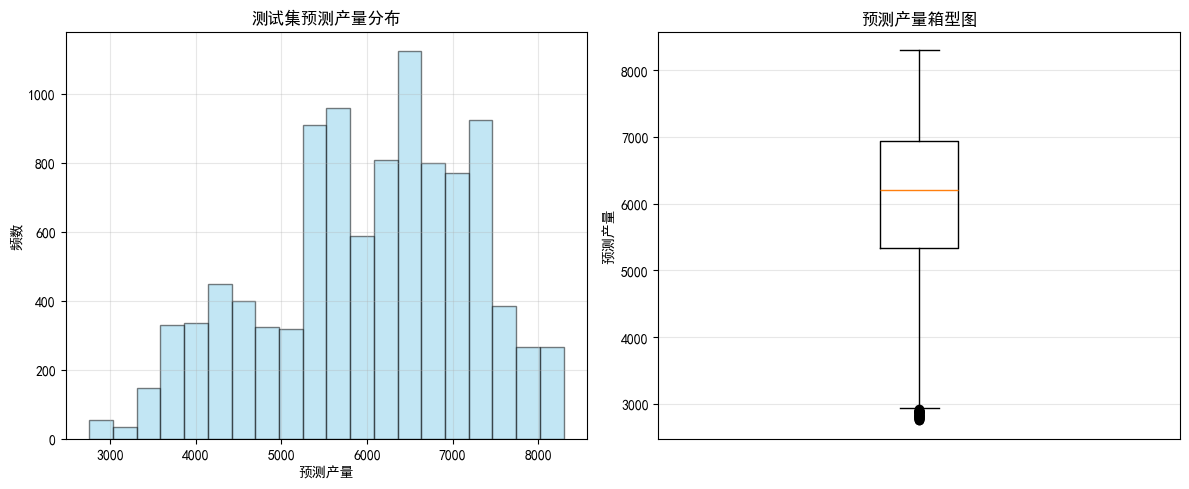

--------------------------------------------------------------------------------
预测完成！
模型验证集 R²: 0.8120
测试集预测样本数: 10194
预测结果文件: submission.csv
--------------------------------------------------------------------------------


In [58]:
# 使用训练好的model来预测test.csv里面的yield
print('-'*80)
print('使用上面的model来预测测试集产量')
print('-'*80)

# 1.先给测试集添加强特征
df_test['total_bees']=df_test['honeybee']*0.6+df_test['bumbles']*1.1+df_test['andrena']*0.8+df_test['osmia']*1

# 果实综合指数，三个指标相乘，反映整体果实表现
df_test['fruit_composite']=df_test['fruitset']*df_test['seeds']*df_test['fruitmass']
# df_test['mass_per_seed'] = df_test['fruitmass'] / (df_test['seeds'] + 1e-8) 单粒种子质量：反映种子饱满度，果实品质的重要指标

# 环境压力特征 温度+雨水，标准化压力指数，Z-score 标准化 Z = (x - 均值) /标准差
df_test['temp_norm']=(df_test['AverageOfUpperTRange']-df_test['AverageOfUpperTRange'].mean())/df_test['AverageOfUpperTRange'].std()
df_test['rain_norm']=(df_test['AverageRainingDays']-df_test['AverageRainingDays'].mean())/df_test['AverageRainingDays'].std()
df_test['stress'] = df_test['temp_norm']*df_test['rain_norm']

# 2.检查测试集是否有这些特征
missing_features=[f for f in best_features if f not in df_test]
if missing_features:
    print(f"测试集缺少以下特征:{missing_features}")
else:
    print(f'用于训练的特征都存在')

# 3.提取特征
X_test=df_test[best_features].copy()

# 4.处理分类变量 测试集也没有分类变量

# 5.处理缺失值 测试集之前检查过没有缺失值
print("\n5.处理缺失值...")
if X_test.isnull().sum().sum() > 0:
    print(f"测试集存在缺失值，用中位数填充")
    # 使用训练集的中位数填充（更规范）
    for col in X_test.columns:
        if X_test[col].isnull().any():
            median_val = df_clean[col].median()  # 使用训练集的中位数
            X_test[col] = X_test[col].fillna(median_val)
            print(f" {col}: 用训练集中位数{median_val:.2f}填充")
else:
    print("无缺失值")


# 5.标准化 上面的cell有加载了scaler(标准化器)和
numeric_features=['clonesize','total_bees','AverageOfUpperTRange',
                 'AverageOfLowerTRange','AverageRainingDays','fruitset',
                 'fruitmass','seeds','fruit_composite','stress']
if 'scaler' in locals() or 'scaler' in globals():
    X_test[numeric_features]=scaler.transform(X_test[numeric_features])
    print("使用训练时的标准化器")
else:
    print('请先用训练集训练一个标准化器')

# 6.加载模型
# 我这里直接承接上面了，所以不用加载

# 7.预测
print('开始预测')
y_pred=model.predict(X_test)
print("预测完成，共{len(y_pred)}个预测值")

# 8.查看预测结果统计
print("\n8. 预测结果统计:")
print(f'预测产量范围:[{y_pred.min():.2f},{y_pred.max():.2f}]')
print(f"预测产量均值: {y_pred.mean():.2f}")
print(f"预测产量标准差:{y_pred.std():.2f}")

# 9.保存预测结果
print("\n9. 保存预测结果...")
submission=pd.DataFrame({
    'id	':df_test['id'],
    'predict_yield':y_pred
})

submission.to_csv('submission.csv',index=False)

# 10.可视化预测结果分布
print("\n10.可视化预测结果...")
plt.figure(figsize=(12, 5))

# 预测值分布
plt.subplot(1,2,1)
# 直方图
plt.hist(y_pred,bins=20,edgecolor='black',alpha=0.5,color='skyblue')
plt.xlabel('预测产量')
plt.ylabel('频数')
plt.title('测试集预测产量分布')
plt.grid(True, alpha=0.3)

# 箱线图
plt.subplot(1,2,2)
plt.boxplot(y_pred,vert=True)
plt.ylabel('预测产量')
plt.xticks([])
plt.title('预测产量箱型图')
plt.grid(True,alpha=0.3)

plt.savefig('预测产量分布.png',dpi=600,bbox_inches='tight')

plt.tight_layout()
plt.show()

print('-'*80)
print("预测完成！")
print(f"模型验证集 R²: 0.8120")
print(f"测试集预测样本数: {len(y_pred)}")
print(f"预测结果文件: submission.csv")
print('-'*80)

In [65]:
df_test.head()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,...,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,total_bees,fruit_composite,temp_norm,rain_norm,stress
0,15289,25.0,0.25,0.25,0.25,0.25,86.0,52.0,71.9,62.0,...,24.0,0.39,0.399367,0.408088,31.394569,0.875,5.116590,0.420023,0.408236,0.171469
1,15290,12.5,0.25,0.25,0.75,0.63,94.6,57.2,79.0,68.2,...,1.0,0.10,0.488048,0.442866,36.846956,1.655,7.964088,1.348416,-1.345706,-1.814572
2,15291,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,...,16.0,0.26,0.583379,0.487057,40.037644,1.559,11.376240,0.420023,-0.378014,-0.158775
3,15292,25.0,0.50,0.38,0.38,0.63,86.0,52.0,71.9,62.0,...,16.0,0.26,0.433014,0.422847,33.116091,1.652,6.063511,0.420023,-0.378014,-0.158775
4,15293,37.5,0.75,0.25,0.25,0.25,94.6,57.2,79.0,68.2,...,24.0,0.39,0.360996,0.388860,29.558019,1.175,4.149263,1.348416,0.408236,0.550472


# 随机森林回归的R²=0.8120，达到可用水平，现在试一下其他的算法

In [35]:
!pip install xgboost lightgbm catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 217.9 kB/s eta 0:07:38
   ---------------------------------------- 0.5/100.2 MB 217.9 kB/s eta 0:07:38
   ---------------------------------------- 0.5/100.2 MB 21

In [54]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models={
    'XGBoost':XGBRegressor(n_estimators=100,learning_rate=0.05,random_state=42,verbosity=0),
    'LightGBM':LGBMRegressor(n_estimators=100,learning_rate=0.05,random_state=42,verbose=-1),
    'CatBoost':CatBoostRegressor(n_estimators=100,learning_rate=0.05,random_state=42,verbose=0)
}

for name,model in models.items():
    print('-'*80)
    model.fit(X_train,y_train)
    y_pred=model.predict(X_val)
    r2=r2_score(y_val,y_pred)
    print(f"{name}验证集R²={r2:.4f}")

--------------------------------------------------------------------------------
XGBoost验证集R²=0.8233
--------------------------------------------------------------------------------
LightGBM验证集R²=0.8254
--------------------------------------------------------------------------------
CatBoost验证集R²=0.8201


In [55]:
# 试试集成一下这几个模型
from sklearn.ensemble import VotingRegressor

ensemble=VotingRegressor(
    [
        ('rf',RandomForestRegressor(n_estimators=100, random_state=42)),
        ('xgb',XGBRegressor(n_estimators=100,learning_rate=0.05,random_state=42,verbosity=0)),
        ('lgb',LGBMRegressor(n_estimators=100,learning_rate=0.05,random_state=42,verbose=-1)),
        ('catb',CatBoostRegressor(n_estimators=100,learning_rate=0.05,random_state=42,verbose=0))
    ]
)

ensemble.fit(X_train,y_train)
val_r2=r2_score(y_val,ensemble.predict(X_val))
print(f'集成模型R²={val_r2:.4f}')

集成模型R²=0.8253
